# A/B-тестирование посадочных страниц туристического сайта

## Цель проекта
Оценить эффективность двух вариантов посадочной страницы (A — контрольный, B — тестовый) по ключевым бизнес-метрикам:
- Конверсия в покупку тура
- Средний чек (сумма покупки)

На основе результатов теста принять обоснованное решение: какой вариант внедрять для роста выручки.

## Данные
- Период: 2–24 января 2021 года
- Записи о посещениях сайта: `user_id`, `date`, `group` (A/B), `purchase` (0/1), `price` (цена тура или 0)
- Туры и цены:
  - Санкт-Петербург — 10 000 ₽
  - Турция — 60 000 ₽
  - Таиланд — 100 000 ₽
  - Камчатка — 150 000 ₽
  - Мальдивы — 200 000 ₽

## План анализа
1. **Предобработка данных**  
   Очистка, удаление пересекающихся пользователей, проверка длительности теста.
2. **Первичный анализ**  
   Сравнение групп по посещениям, покупкам, выручке, конверсии, среднему чеку и продажам по турам.
3. **Анализ стабилизации метрик**  
   Кумулятивные графики конверсии и среднего чека.
4. **Статистический анализ**  
   Проверка значимости различий (Z-тест для конверсии, t-тест/Mann-Whitney для чека), доверительные интервалы.
5. **Выводы и рекомендация**  
   Какой вариант страницы выбрать и почему.

Проект выполнен в Jupyter Notebook / VS Code с использованием Python (pandas, matplotlib, scipy, statsmodels).

In [63]:
# Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.stats.api as sms

In [64]:
# Загрузка данных
data = pd.read_csv('data/ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


In [65]:
# Исследование структуры данных
print("\nИнформация о данных:")
print(data.info())
print("\nСтатистическое описание:")
print(data.describe())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB
None

Статистическое описание:
             user_id       purchase          price
count  294478.000000  294478.000000  294478.000000
mean   787974.124733       0.119659   10154.782361
std     91210.823776       0.324563   35153.824872
min    630000.000000       0.000000       0.000000
25%    709032.250000       0.000000       0.000000
50%    787933.500000       0.000000       0.000000
75%    866911.750000       0.000000       0.000000
max    945999.000000       1.000000  200000.000000


In [66]:
# Преобразование столбцов к необходимым типам
# Преобразование даты к datetime
data['date'] = pd.to_datetime(data['date'])  

In [67]:
# Проверка длительности A/B-тестирования в группах
group_a = data[data['group'] == 'A']
group_b = data[data['group'] == 'B']

min_date_a = group_a['date'].min()
max_date_a = group_a['date'].max()
min_date_b = group_b['date'].min()
max_date_b = group_b['date'].max()

print("\nДлительность для группы A: от", min_date_a, "до", max_date_a)
print("Длительность для группы B: от", min_date_b, "до", max_date_b)


Длительность для группы A: от 2021-01-02 00:00:00 до 2021-01-24 00:00:00
Длительность для группы B: от 2021-01-02 00:00:00 до 2021-01-24 00:00:00


In [68]:
# Унификация длительности, если отличается
if min_date_a != min_date_b or max_date_a != max_date_b:
    overall_min_date = max(min_date_a, min_date_b)
    overall_max_date = min(max_date_a, max_date_b)
    data = data[(data['date'] >= overall_min_date) & (data['date'] <= overall_max_date)]
    print("\nДанные унифицированы по датам: от", overall_min_date, "до", overall_max_date)

In [69]:
# Проверка на пропуски
print("\nПропуски в данных:")
print(data.isnull().sum())


Пропуски в данных:
user_id     0
date        0
group       0
purchase    0
price       0
dtype: int64


In [70]:
# Удаление строк с пропусками, если они есть
data = data.dropna()

In [71]:
# Проверка пользователей в обеих группах
duplicated_users = data.groupby('user_id')['group'].nunique()
duplicated_users = duplicated_users[duplicated_users > 1].index

if len(duplicated_users) > 0:
    print("\nНайдено пользователей в обеих группах:", len(duplicated_users))
    data = data[~data['user_id'].isin(duplicated_users)]
    print("Исключены пользователи, попавшие в обе группы.")
else:
    print("\nНет пользователей, попавших в обе группы.")


Найдено пользователей в обеих группах: 1895
Исключены пользователи, попавшие в обе группы.


In [72]:
# Финальная проверка данных
print("\nФинальная информация о данных после предобработки:")
print(data.info())
print("\nПервые 5 строк после предобработки:")
print(data.head())


Финальная информация о данных после предобработки:
<class 'pandas.core.frame.DataFrame'>
Index: 290688 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   user_id   290688 non-null  int64         
 1   date      290688 non-null  datetime64[ns]
 2   group     290688 non-null  object        
 3   purchase  290688 non-null  int64         
 4   price     290688 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 13.3+ MB
None

Первые 5 строк после предобработки:
   user_id       date group  purchase   price
0   851104 2021-01-21     A         0       0
1   804228 2021-01-12     A         0       0
2   661590 2021-01-11     B         0       0
3   853541 2021-01-08     B         0       0
4   864975 2021-01-21     A         1  150000


# Предобработка A/B-теста

## Исходно
- Записей: 294 478
- Пропусков: нет

## Действия
- `date` → datetime
- Даты теста совпадают (02–24.01.2021)
- Удалено 1 895 пользователей из обеих групп

## Итог
- Записей: 290 688
- Данные чистые, готовы к анализу

In [73]:
# Вспомогательные показатели
groups = data.groupby('group').agg(
    visits=('user_id', 'count'),
    purchases=('purchase', 'sum'),
    total_revenue=('price', 'sum')
).reset_index()

print("Вспомогательные показатели:")
print(groups)

Вспомогательные показатели:
  group  visits  purchases  total_revenue
0     A  145307      17487     1417780000
1     B  145381      17290     1533010000


In [74]:
# Ключевые показатели
groups['conversion'] = (groups['purchases'] / groups['visits']) * 100
groups['avg_check'] = groups['total_revenue'] / groups['purchases']

print("\nКлючевые показатели:")
print(groups[['group', 'conversion', 'avg_check']])


Ключевые показатели:
  group  conversion     avg_check
0     A   12.034520  81076.228055
1     B   11.892888  88664.545980


In [75]:
# Сводная таблица по турам
# Фильтр только покупок (purchase == 1)
purchases_data = data[data['purchase'] == 1]

pivot = pd.pivot_table(
    purchases_data,
    values='purchase',
    index='price',
    columns='group',
    aggfunc='count',
    fill_value=0
).reset_index()

# Переименовать для ясности
pivot.columns = ['price', 'A', 'B']
pivot['tour'] = pivot['price'].map({
    10000: 'Санкт-Петербург',
    60000: 'Турция',
    100000: 'Таиланд',
    150000: 'Камчатка',
    200000: 'Мальдивы'
})

print("\nСводная таблица по турам:")
print(pivot)


Сводная таблица по турам:
    price     A     B             tour
0   10000  5182  5201  Санкт-Петербург
1   60000  5271  1730           Турция
2  100000  1832  5227          Таиланд
3  150000  3478  3438         Камчатка
4  200000  1724  1694         Мальдивы


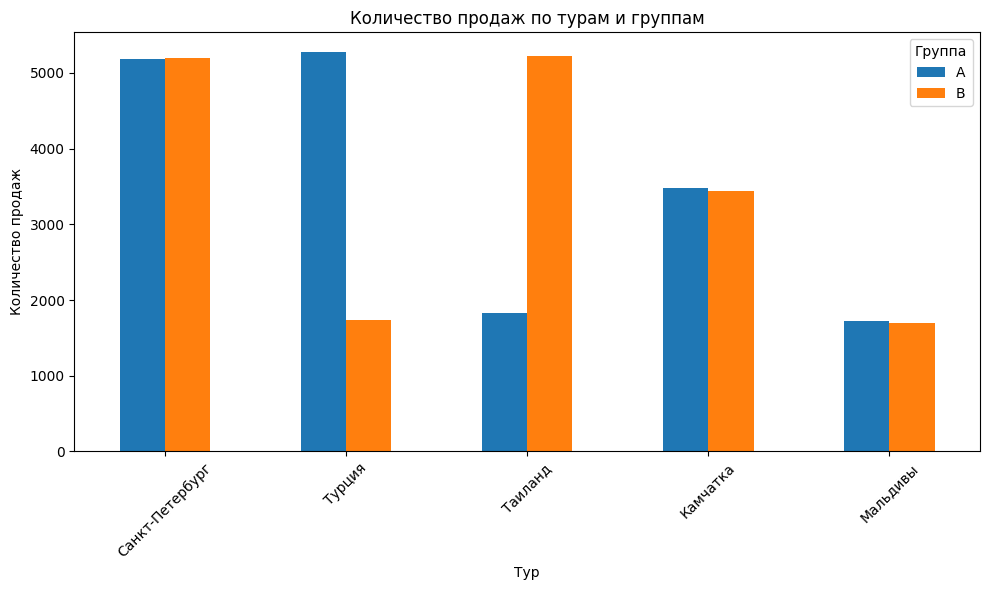

In [76]:
# Визуализация
pivot.plot(x='tour', y=['A', 'B'], kind='bar', figsize=(10, 6))
plt.title('Количество продаж по турам и группам')
plt.xlabel('Тур')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.legend(title='Группа')
plt.tight_layout()
plt.show()

# Первичный анализ A/B-теста

## Вспомогательные показатели
| Группа | Посещений | Покупок | Выручка     |
|--------|-----------|---------|-------------|
| A      | 145 307   | 17 487  | 1 417 780 000 |
| B      | 145 381   | 17 290  | 1 533 010 000 |

- Посещений почти поровну (разница <0.1%) → выборки сбалансированы.

## Ключевые метрики
| Группа | Конверсия (%) | Средний чек   |
|--------|---------------|---------------|
| A      | 12.03         | 81 076        |
| B      | 11.89         | 88 665        |

- Конверсия чуть выше в A (+0.14 п.п.).
- Средний чек заметно выше в B (+9.4%).

## Продажи по турам
| Тур              | Цена    | A     | B     |
|------------------|---------|-------|-------|
| Санкт-Петербург  | 10 000  | 5 182 | 5 201 |
| Турция           | 60 000  | 5 271 | 1 730 |
| Таиланд          | 100 000 | 1 832 | 5 227 |
| Камчатка         | 150 000 | 3 478 | 3 438 |
| Мальдивы         | 200 000 | 1 724 | 1 694 |

- A доминирует в дешёвых турах (Турция).
- B сильно выигрывает в средних турах (Таиланд).

Вывод: A лучше по конверсии, B — по чеку и выручке за счёт сдвига в более дорогие туры.

In [77]:
# Ежедневные данные
daily_data = data.groupby(['date', 'group']).agg(
    visits=('user_id', 'count'),
    purchases=('purchase', 'sum'),
    revenue=('price', 'sum')
).reset_index()

In [78]:
# Ежедневные метрики (конверсия в долях, обработка NaN для avg_check)
daily_data['conversion'] = daily_data['purchases'] / daily_data['visits']
daily_data['avg_check'] = daily_data['revenue'] / daily_data['purchases']
daily_data['avg_check'] = daily_data['avg_check'].fillna(0)

print("Ежедневные данные:")
print(daily_data.head())

Ежедневные данные:
        date group  visits  purchases   revenue  conversion     avg_check
0 2021-01-02     A    2854        359  29410000    0.125788  81922.005571
1 2021-01-02     B    2861        345  29660000    0.120587  85971.014493
2 2021-01-03     A    6596        748  62000000    0.113402  82887.700535
3 2021-01-03     B    6619        754  65960000    0.113914  87480.106101
4 2021-01-04     A    6566        799  64250000    0.121687  80413.016270


In [79]:
# Кумулятивные показатели
daily_data = daily_data.sort_values(['group', 'date'])
daily_data['cum_visits'] = daily_data.groupby('group')['visits'].cumsum()
daily_data['cum_purchases'] = daily_data.groupby('group')['purchases'].cumsum()
daily_data['cum_revenue'] = daily_data.groupby('group')['revenue'].cumsum()

In [80]:
# Кумулятивные метрики
daily_data['cum_conversion'] = daily_data['cum_purchases'] / daily_data['cum_visits']
daily_data['cum_avg_check'] = daily_data['cum_revenue'] / daily_data['cum_purchases']
daily_data['cum_avg_check'] = daily_data['cum_avg_check'].fillna(0)

print("\nДанные с кумулятивными метриками:")
print(daily_data.head())


Данные с кумулятивными метриками:
        date group  visits  purchases   revenue  conversion     avg_check  \
0 2021-01-02     A    2854        359  29410000    0.125788  81922.005571   
2 2021-01-03     A    6596        748  62000000    0.113402  82887.700535   
4 2021-01-04     A    6566        799  64250000    0.121687  80413.016270   
6 2021-01-05     A    6433        790  64550000    0.122804  81708.860759   
8 2021-01-06     A    6606        764  63410000    0.115652  82997.382199   

   cum_visits  cum_purchases  cum_revenue  cum_conversion  cum_avg_check  
0        2854            359     29410000        0.125788   81922.005571  
2        9450           1107     91410000        0.117143   82574.525745  
4       16016           1906    155660000        0.119006   81668.415530  
6       22449           2696    220210000        0.120094   81680.267062  
8       29055           3460    283620000        0.119084   81971.098266  


C:\Users\mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a le

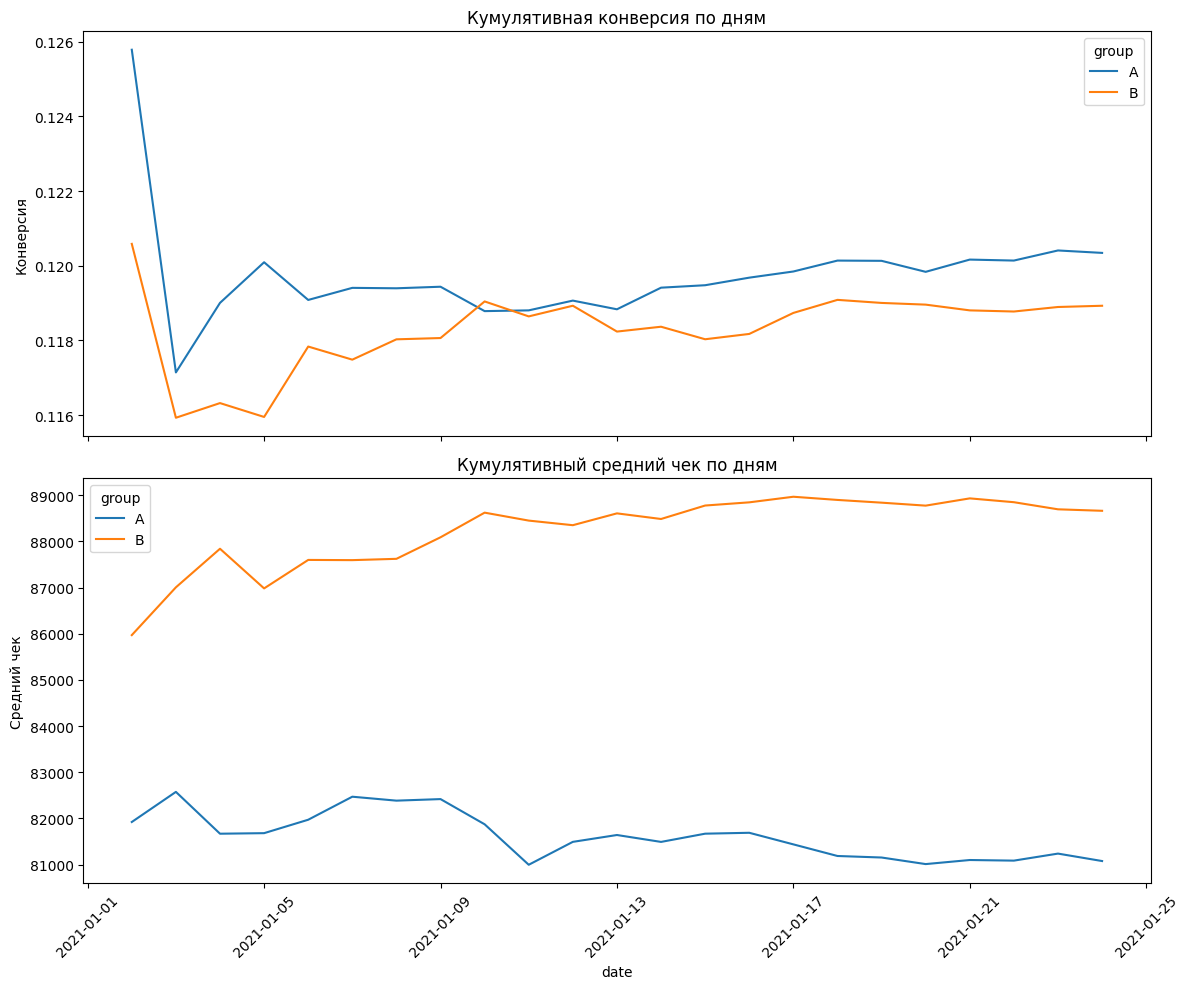

In [81]:
# Графики
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Кумулятивная конверсия
sns.lineplot(data=daily_data, x='date', y='cum_conversion', hue='group', ax=axes[0])
axes[0].set_title('Кумулятивная конверсия по дням')
axes[0].set_ylabel('Конверсия')

# Кумулятивный средний чек
sns.lineplot(data=daily_data, x='date', y='cum_avg_check', hue='group', ax=axes[1])
axes[1].set_title('Кумулятивный средний чек по дням')
axes[1].set_ylabel('Средний чек')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Анализ стабилизации метрик A/B-теста

## Кумулятивные графики (наблюдения)
- **Конверсия**: 
  - Стабилизировалась после ~10–12 января.
  - Группа A стабильно выше B на 0.1–0.2 п.п. (финал: A ≈12.03%, B ≈11.89%).

- **Средний чек**: 
  - Стабилизировался к концу теста (после 15–18 января).
  - Группа B уверенно выше A (финал: B ≈88 665, A ≈81 076).

## Выводы
- Метрики стабилизировались во второй половине теста.
- A/B-тест можно считать завершённым: колебания минимальны, тренды устойчивы.
- A выигрывает по конверсии, B — по среднему чеку.

Готовы к статистической проверке значимости различий.

In [82]:
# Группы
group_a = data[data['group'] == 'A']
group_b = data[data['group'] == 'B']

# Конверсии: гипотезы и тест
# H0: p_A = p_B (конверсии равны)
# H1: p_A ≠ p_B
# Тест: Z-тест для пропорций (большие выборки, норм. аппрокс. ок, np>10)

purchases_a = group_a['purchase'].sum()
purchases_b = group_b['purchase'].sum()
n_a = len(group_a)
n_b = len(group_b)

count = np.array([purchases_a, purchases_b])
nobs = np.array([n_a, n_b])
z_stat, p_val_conv = proportions_ztest(count, nobs)

print(f"Z-статистика для конверсий: {z_stat:.4f}")
print(f"p-value для конверсий: {p_val_conv:.4f}")

Z-статистика для конверсий: 1.1765
p-value для конверсий: 0.2394


In [83]:
# 2. Ежедневные средние чеки:
daily_data = data[data['purchase'] == 1].groupby(['date', 'group'])['price'].mean().reset_index(name='avg_check')
daily_a = daily_data[daily_data['group'] == 'A']['avg_check'].dropna()
daily_b = daily_data[daily_data['group'] == 'B']['avg_check'].dropna()


# Проверка нормальности
shapiro_a = stats.shapiro(daily_a)
shapiro_b = stats.shapiro(daily_b)

print(f"Shapiro A: stat={shapiro_a.statistic:.4f}, p={shapiro_a.pvalue:.4f}")
print(f"Shapiro B: stat={shapiro_b.statistic:.4f}, p={shapiro_b.pvalue:.4f}")

# Гипотезы: H0: mu_A = mu_B, H1: ≠
# Если норм (p>0.05 оба), t-тест; иначе Mann-Whitney
if shapiro_a.pvalue > 0.05 and shapiro_b.pvalue > 0.05:
    t_stat, p_val_check = stats.ttest_ind(daily_a, daily_b)
    test_name = "t-тест"
else:
    u_stat, p_val_check = stats.mannwhitneyu(daily_a, daily_b)
    test_name = "Mann-Whitney"

print(f"{test_name} p-value для чеков: {p_val_check:.4f}")

Shapiro A: stat=0.9470, p=0.2531
Shapiro B: stat=0.9269, p=0.0938
t-тест p-value для чеков: 0.0000


In [84]:
# Доверительные интервалы 95%
# Конверсии групп
ci_a_conv = proportion_confint(purchases_a, n_a, method='wilson')
ci_b_conv = proportion_confint(purchases_b, n_b, method='wilson')

print(f"CI конверсия A: {ci_a_conv}")
print(f"CI конверсия B: {ci_b_conv}")

# Разница конверсий (A - B)
alpha = 0.05
diff = group_a['purchase'].mean() - group_b['purchase'].mean()
se_diff = np.sqrt(group_a['purchase'].var()/n_a + group_b['purchase'].var()/n_b)
ci_diff = stats.norm.interval(1-alpha, loc=diff, scale=se_diff)

print(f"CI разницы конверсий: {ci_diff}")

# Средние чеки (ежедневные, предполагаем норм или используем t)
ci_a_check = stats.t.interval(1-alpha, len(daily_a)-1, loc=daily_a.mean(), scale=stats.sem(daily_a))
ci_b_check = stats.t.interval(1-alpha, len(daily_b)-1, loc=daily_b.mean(), scale=stats.sem(daily_b))

print(f"CI средний чек A: {ci_a_check}")
print(f"CI средний чек B: {ci_b_check}")

CI конверсия A: (0.11868230810530649, 0.12202816544000698)
CI конверсия B: (0.11727498180653662, 0.12060292287595631)
CI разницы конверсий: (-0.000943232278844186, 0.003775865770318576)
CI средний чек A: (79630.35138233882, 82308.21881567157)
CI средний чек B: (87625.82583631018, 89525.6051909103)


# Вывод по A/B-тесту посадочных страниц

## Предобработка
- Исходно: 294 478 записей, без пропусков.
- Исключено 1 895 пользователей из обеих групп.
- Итог: 290 688 записей, группы сбалансированы (A: 145 307, B: 145 381).

## Первичный анализ
- Конверсия: A — 12.03%, B — 11.89%.
- Средний чек: A — 81 076 ₽, B — 88 665 ₽.
- Выручка: A — 1.42 млрд ₽, B — 1.53 млрд ₽.
- B доминирует в дорогих турах (Таиланд: +185%), A — в бюджетных (Турция, СПб).

## Стабилизация метрик
- Кумулятивные графики: метрики стабилизировались к середине/концу теста.
- Тест завершён корректно, данные достаточны.

## Статистический анализ
- Конверсия: различия не значимы (p=0.24), ДИ перекрываются.
- Средний чек: значимо выше в B (p<0.001), ДИ не перекрываются.

## Рекомендация
Вариант B эффективнее: равная конверсия, но чек выше на 9.4%, выручка +8%. B стимулирует покупки премиум-туров. Надо внедрять B, поскольку A не даёт преимуществ и снижает доход.